In [1]:
pip install pyabf xgboost scikit-learn numpy scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 5.0 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [64]:
import pyabf
import numpy as np
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

In [66]:
# ---------------------------------------------------------
# 1. Peak detection function
# ---------------------------------------------------------
def detect_peaks_in_voltage_clamp(
    abf_file, protocol="3_VC_EPSCs", prominence=10, height=None,
    distance=None, plot=True
):
    """
    Detect peaks (e.g., EPSCs) in a voltage clamp ABF file using scipy.signal.find_peaks.
    Returns dictionary of sweeps with peak times, indices, and amplitudes.
    """
    abf = pyabf.ABF(abf_file)

    # Confirm this is a voltage clamp
    if not any(unit in abf.sweepLabelY for unit in ["pA", "nA"]):
        raise ValueError(f"{abf_file} does not appear to be a voltage clamp recording.")
    if abf.protocol != protocol:
        raise ValueError(f"{abf_file} protocol is {abf.protocol}, expected {protocol}")

    sweep_data = {}
    sampling_rate = abf.dataRate  # Hz

    for sweep in range(abf.sweepCount):
        abf.setSweep(sweep)
        current_trace = abf.sweepY
        time_ms = abf.sweepX * 1000

        # Invert signal to detect negative-going peaks
        inverted_trace = -current_trace

        peaks, properties = find_peaks(
            inverted_trace, prominence=prominence, height=height, distance=distance
        )

        peak_times_ms = time_ms[peaks]
        peak_amplitudes_pA = current_trace[peaks]

        sweep_data[sweep] = {
            "peak_times_ms": peak_times_ms.tolist(),
            "peak_indices": peaks.tolist(),
            "peak_amplitudes_pA": peak_amplitudes_pA.tolist(),
        }

        print(f"Sweep {sweep}: Found {len(peaks)} peaks")

        if plot:
            plt.figure(figsize=(10, 4))
            plt.plot(time_ms, current_trace, color="blue", lw=0.5, label="Raw Data")
            plt.plot(peak_times_ms, peak_amplitudes_pA, "rx", label="Detected Peaks")
            plt.xlabel("Time (ms)")
            plt.ylabel(f"Current ({abf.sweepUnitsY})")
            plt.title(f"Sweep {sweep}: Detected Peaks")
            plt.legend()
            plt.grid(True)
            plt.show()

    return sweep_data, sampling_rate

In [68]:
# ---------------------------------------------------------
# 2. Build dataset (baseline snippets + latencies)
# ---------------------------------------------------------
def build_latency_dataset(abf_file, baseline_window_ms=200,
                          protocol="3_VC_EPSCs", prominence=10, height=None,
                          distance=None, plot=False):
    sweep_data, sampling_rate = detect_peaks_in_voltage_clamp(
        abf_file, protocol=protocol, prominence=prominence,
        height=height, distance=distance, plot=plot
    )
    abf = pyabf.ABF(abf_file)

    baseline_points = int(baseline_window_ms * sampling_rate / 1000)

    X = []
    y = []

    for sweep in range(abf.sweepCount):
        abf.setSweep(sweep)
        trace = abf.sweepY

        peaks = sweep_data[sweep]["peak_indices"]
        peak_times_ms = sweep_data[sweep]["peak_times_ms"]

        for i in range(len(peaks) - 1):  # up to second-to-last peak
            event_idx = peaks[i]
            latency_ms = peak_times_ms[i+1] - peak_times_ms[i]

            # Skip if not enough baseline before this event
            if event_idx - baseline_points < 0:
                continue

            snippet = trace[event_idx - baseline_points:event_idx]
            snippet = (snippet - np.mean(snippet)) / (np.std(snippet) + 1e-6)

            X.append(snippet)
            y.append(latency_ms)

    X = np.array(X)
    y = np.array(y)
    print(f"Dataset built: {X.shape[0]} samples, each {X.shape[1]} points")
    return X, y

# ---------------------------------------------------------
# 3. Train regression model (with scatter plot)
# ---------------------------------------------------------
def train_latency_model(X, y, test_size=0.2):
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import mean_absolute_error
    from xgboost import XGBRegressor

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    # Flatten for XGBoost
    X_train_flat = X_train.reshape(X_train.shape[0], -1)
    X_test_flat = X_test.reshape(X_test.shape[0], -1)

    model = XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    model.fit(X_train_flat, y_train)
    y_pred = model.predict(X_test_flat)

    mae = mean_absolute_error(y_test, y_pred)
    print(f"Mean Absolute Error: {mae:.2f} ms")

    # --- Scatter plot: True vs Predicted ---
    plt.figure(figsize=(6, 6))
    plt.scatter(y_test, y_pred, alpha=0.6, edgecolor="k")
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], "r--", label="Ideal")
    plt.xlabel("True Latency (ms)")
    plt.ylabel("Predicted Latency (ms)")
    plt.title("True vs Predicted Latencies")
    plt.legend()
    plt.grid(True)
    plt.show()

    return model, (X_test, y_test, y_pred)

Sweep 0: Found 1131 peaks
Sweep 1: Found 1146 peaks
Sweep 2: Found 1244 peaks
Sweep 3: Found 1260 peaks
Sweep 4: Found 1336 peaks
Sweep 5: Found 1470 peaks
Sweep 6: Found 1546 peaks
Sweep 7: Found 1555 peaks
Sweep 8: Found 1576 peaks
Sweep 9: Found 1665 peaks
Sweep 10: Found 1681 peaks
Sweep 11: Found 1667 peaks
Sweep 12: Found 1651 peaks
Sweep 13: Found 1731 peaks
Sweep 14: Found 1697 peaks
Sweep 15: Found 1707 peaks
Sweep 16: Found 1685 peaks
Sweep 17: Found 1639 peaks
Sweep 18: Found 1710 peaks
Sweep 19: Found 1662 peaks
Sweep 20: Found 1750 peaks
Sweep 21: Found 1765 peaks
Sweep 22: Found 1806 peaks
Sweep 23: Found 1777 peaks
Sweep 24: Found 1712 peaks
Sweep 25: Found 1764 peaks
Sweep 26: Found 1796 peaks
Sweep 27: Found 1789 peaks
Sweep 28: Found 1846 peaks
Sweep 29: Found 1753 peaks
Sweep 30: Found 1777 peaks
Sweep 31: Found 1686 peaks
Sweep 32: Found 1675 peaks
Sweep 33: Found 1763 peaks
Sweep 34: Found 1720 peaks
Sweep 35: Found 1662 peaks
Sweep 36: Found 1641 peaks
Sweep 37: F

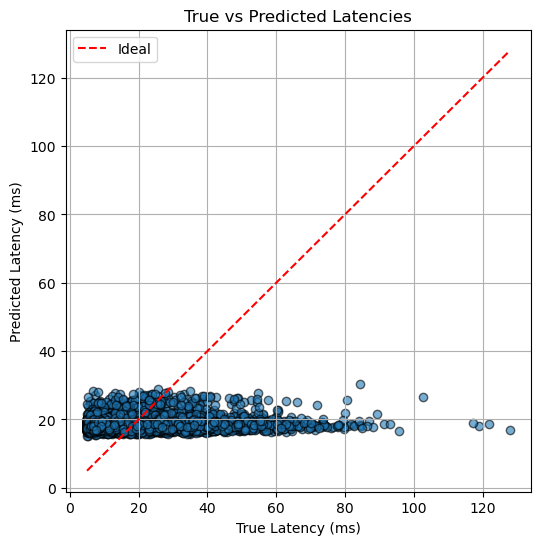

In [70]:
# ---------------------------------------------------------
# Example usage
# ---------------------------------------------------------
if __name__ == "__main__":
    abf_file = "/Users/jayashri/Desktop/25609011.abf"
    X, y = build_latency_dataset(abf_file, baseline_window_ms=200,
                                 prominence=10, distance=50, plot=False)
    model, results = train_latency_model(X, y)